# Fitting (Recurrent) AR-HMMs to Neural Data
### MCN 2026 Tutorial &mdash; Scott Linderman

<a target="_blank" href="https://colab.research.google.com/github/slinderman/mcn2026/blob/main/arhmm_tutorial.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In lecture, we built up a spectrum of dynamics models &mdash; linear dynamical systems (LDS), switching LDS, **recurrent SLDS**, and Gaussian process SLDS &mdash; to
uncover a line attractor in the hypothalamus (VMHvl), and we saw that Motion Sequencing (**MoSeq**), our
model of behavioral syllables, is built on an **autoregressive HMM (AR-HMM)**.

In this tutorial we'll fit AR-HMMs to real neural data &mdash; the same VMHvl recording presented in lecture &mdash; and:

1. Load and explore the real data.
2. Fit an AR-HMM and **select the number of discrete states $K$ by cross-validation**.
3. Extend the model to a **recurrent** AR-HMM &mdash; the same trick that turns an SLDS into an rSLDS &mdash;
   and **visualize its inferred flow field**, just as we did for rSLDS/gpSLDS in lecture.

**A note on software.** This tutorial is built on [`ssm`](https://github.com/lindermanlab/ssm), the original Python library we developed for state space models, including the rSLDS. More recently, we have developed [`Dynamax`](https://github.com/probml/dynamax), a library for state space modeling with JAX, which supports GPU acceleration. In my lab, we also have new research libraries like [`SING`](https://github.com/lindermanlab/sing), which implement algorithms for Gaussian process state space models in JAX as well.

In [1]:
# Install dependencies. `ssm` compiles a small Cython extension the first
# time, so this may take ~1 minute. --no-build-isolation is required so its
# setup.py can see the numpy/cython we just installed.
try:
    import ssm
except ImportError:
    print("Installing ssm...")
    !pip install -q numpy cython setuptools wheel
    !pip install -q --no-build-isolation git+https://github.com/lindermanlab/ssm.git
    import ssm

try:
    import lindi
except ImportError:
    print("Installing lindi...")
    !pip install -q lindi
    import lindi

In [2]:
import time

import numpy as np
import numpy.random as npr
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import ssm

npr.seed(0)
colors = plt.cm.tab10.colors

fontsize = 14
labelsize = 11

## Load real neural data

This is the same dataset used in the gpSLDS/SING lecture demo: calcium imaging of VMHvl during aggressive
behavior (Vinograd, Nair et al., *Nature* 2024), hosted on DANDI and streamed with `lindi` so there's
nothing to download by hand.

In [3]:
url = 'https://api.dandiarchive.org/api/assets/1e11c74e-6f25-4604-9216-5b861fec8f1c/download/'

# Stream the remote NWB file
f = lindi.LindiH5pyFile.from_hdf5_file(url)
NeuralTrace = f['/processing/ophys/NeuralTrace']
neural = NeuralTrace['data'][:]
rate = 10.  # Hz

n_timesteps, n_neurons = neural.shape
t_max = n_timesteps / rate
t_grid = np.linspace(0, t_max, n_timesteps)
dt = 1. / rate

print(f"shape of neural activity: {neural.shape}")
print(f"{n_neurons} neurons, {n_timesteps} timesteps, {t_max:.1f} seconds @ {rate} Hz")

shape of neural activity: (4201, 56)
56 neurons, 4201 timesteps, 420.1 seconds @ 10.0 Hz


In [4]:
# Z-score each neuron before analysis, same preprocessing as in lecture
norm_neural = (neural - neural.mean(0)) / neural.std(0)

## Exploratory data analysis

Same two views we used in lecture: a heatmap of all neurons over time, and the top 2 PCs, which reveal
low-dimensional structure in the population activity.

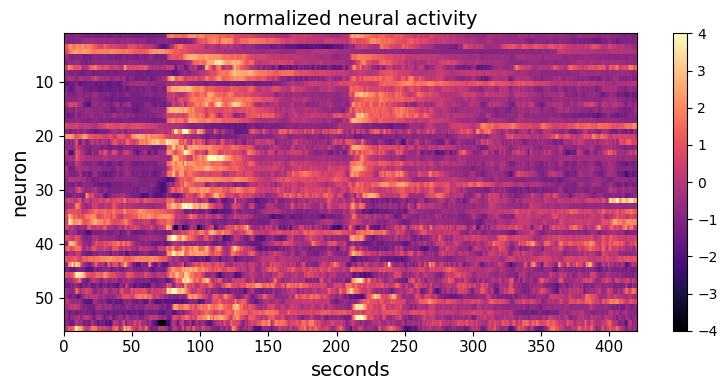

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(
    norm_neural.T,
    aspect='auto',
    extent=[0, t_max, n_neurons, 1],
    interpolation='none',
    vmin=-4, vmax=4,
    cmap='magma'
)
ax.set_xlabel('seconds', fontsize=fontsize)
ax.set_ylabel('neuron', fontsize=fontsize)
ax.set_title('normalized neural activity', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=labelsize)
fig.colorbar(im, ax=ax)
plt.tight_layout()

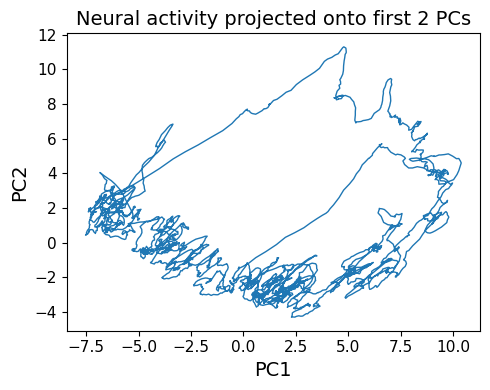

In [6]:
pca = PCA(n_components=2)
neural_pca = pca.fit_transform(norm_neural)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(neural_pca[:, 0], neural_pca[:, 1], lw=1)
ax.set_xlabel('PC1', fontsize=fontsize)
ax.set_ylabel('PC2', fontsize=fontsize)
ax.set_title('Neural activity projected onto first 2 PCs', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=labelsize)
plt.tight_layout()

We'll fit our AR-HMMs directly to this 2D PCA trajectory (`neural_pca`), rather than the full
56-neuron recording. That keeps EM fast enough to run live, and &mdash; just as importantly &mdash; lets
us visualize the inferred dynamics as a 2D flow field, exactly as we did for rSLDS in lecture.

As in the lecture demo, two brief windows of rapidly-changing activity correspond to an intruder mouse
being introduced. We'll construct step-function inputs marking those windows, and reuse them later as
exogenous inputs to the recurrent AR-HMM's transition model.

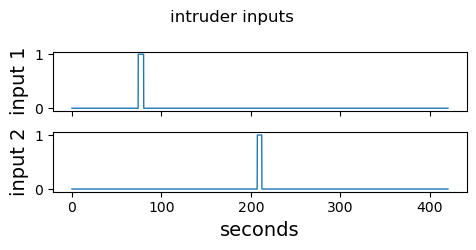

In [7]:
# Time windows (seconds) of the two intruder-entrance events
input1_times = np.array([74, 80])
input2_times = np.array([207, 212])

input1_inds = (input1_times * rate).astype(int)
input2_inds = (input2_times * rate).astype(int)

n_inputs = 2
inputs = np.zeros((n_timesteps, n_inputs))
inputs[input1_inds[0]:input1_inds[1] + 1, 0] = 1.
inputs[input2_inds[0]:input2_inds[1] + 1, 1] = 1.

fig, axs = plt.subplots(n_inputs, 1, figsize=(5, 2.5), sharex=True)
for i, ax in enumerate(axs):
    ax.plot(t_grid, inputs[:, i], lw=1)
    ax.set_ylabel(f'input {i+1}', fontsize=fontsize)
axs[-1].set_xlabel('seconds', fontsize=fontsize)
fig.suptitle('intruder inputs')
plt.tight_layout()

## Part 1: Fitting an AR-HMM

An AR-HMM is the model underneath MoSeq (once called "sHDP-AR-HMM"), and it's the discrete-only cousin of
an SLDS: there's no separate continuous latent state, the autoregressive dynamics act directly on the
(here, 2D PCA-projected) data.

$$
z_t \sim \mathrm{Cat}(\pi_{z_{t-1}}), \qquad x_t \mid z_t = k \sim N(A_k x_{t-1} + b_k,\ \Sigma_k)
$$

Let's fit one with a handful of states just to see it work, before we worry about choosing $K$
properly.

In [8]:
def plot_trajectory(z, x, ax=None, ls="-", lw=1):
    '''Plot a 2D trajectory x, colored by discrete state sequence z.'''
    zcps = np.concatenate(([0], np.where(np.diff(z))[0] + 1, [z.size]))
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    for start, stop in zip(zcps[:-1], zcps[1:]):
        ax.plot(x[start:stop + 1, 0], x[start:stop + 1, 1],
                lw=lw, ls=ls, color=colors[z[start] % len(colors)])
    return ax

def plot_observations(z, y, ax=None, ls="-", lw=1):
    '''Plot each column of y over time, colored by discrete state sequence z.'''
    zcps = np.concatenate(([0], np.where(np.diff(z))[0] + 1, [z.size]))
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 3))
    T, N = y.shape
    t = np.arange(T)
    for n in range(N):
        for start, stop in zip(zcps[:-1], zcps[1:]):
            ax.plot(t[start:stop + 1], y[start:stop + 1, n],
                    lw=lw, ls=ls, color=colors[z[start] % len(colors)])
    return ax

In [9]:
D = 2       # dimensionality of the (PCA-projected) data
K0 = 4      # number of discrete states, just to get started

arhmm = ssm.HMM(K0, D, observations="autoregressive")
arhmm.fit(neural_pca, method="em", num_iters=100, verbose=2)
zhat = arhmm.most_likely_states(neural_pca)

  0%|          | 0/100 [00:00<?, ?it/s]

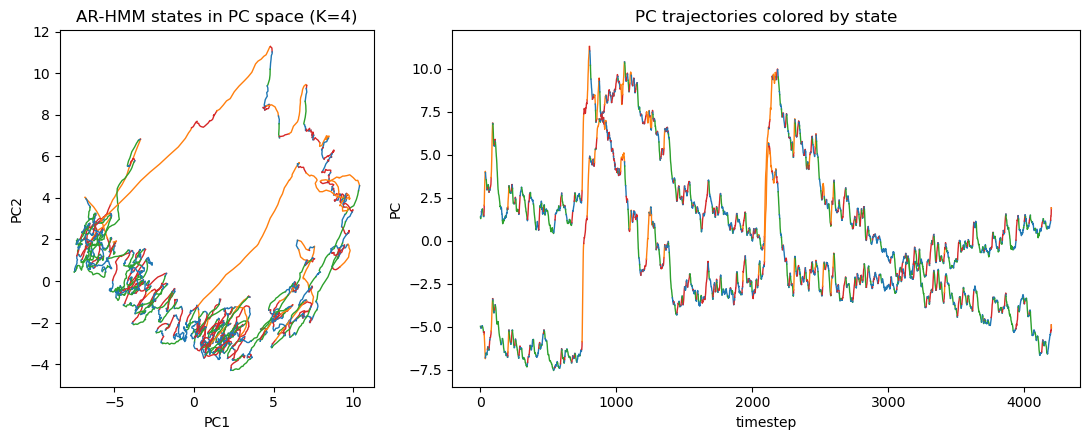

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [1, 2]})
plot_trajectory(zhat, neural_pca, ax=axs[0])
axs[0].set_xlabel('PC1'); axs[0].set_ylabel('PC2')
axs[0].set_title(f'AR-HMM states in PC space (K={K0})')

plot_observations(zhat, neural_pca, ax=axs[1])
axs[1].set_xlabel('timestep'); axs[1].set_ylabel('PC')
axs[1].set_title('PC trajectories colored by state')
plt.tight_layout()

## Part 2: Choosing $K$ by cross-validation

From here on we'll fit AR-HMMs whose observation model uses the inputs directly. So far the autoregressive
mean only depended on the previous timestep, $A_k x_{t-1} + b_k$; `ssm`'s `AutoRegressiveObservations`
class also supports an input term out of the box:

$$
x_t \mid z_t = k,\ u_t \ \sim\ N\big(A_k x_{t-1} + B_k u_t + b_k,\ Q_k\big)
$$

(the `ssm` docstring calls the input-weight matrix $V_k$ rather than $B_k$, same idea). This is more
general than the input-free model in Part 1 &mdash; useful to have in your toolkit for other projects during
the course, even in cases like this one where it doesn't end up mattering much for held-out likelihood (see
the note at the end of this notebook).

We picked $K_0 = 4$ out of thin air in Part 1. As in the Dynamax `GaussianHMM` tutorial, we can choose $K$
more carefully by comparing held-out log-likelihood across candidate values &mdash; too few states
underfits, too many overfits and starts explaining noise. The Dynamax example had several independent
trials to fold over; we only have one continuous 420-second recording, so instead we'll split it into
contiguous chunks and do **leave-one-chunk-out** cross-validation &mdash; folding on blocks preserves the
short-timescale autocorrelation within each chunk, which a random per-timestep split would break.

**A $K=1$ baseline.** It's worth including $K=1$ in the sweep too &mdash; a single global linear-Gaussian
AR model with no discrete switching at all, the natural floor that any switching model should beat. With
only one state there's nothing to switch between, so the whole model collapses to ordinary least-squares
regression of $x_t$ on $(x_{t-1}, u_t, 1)$, with $Q$ the empirical residual covariance. 

In [11]:
def make_chunks(data, inputs, n_chunks):
    T = data.shape[0]
    edges = np.linspace(0, T, n_chunks + 1).astype(int)
    data_chunks = [data[edges[i]:edges[i + 1]] for i in range(n_chunks)]
    input_chunks = [inputs[edges[i]:edges[i + 1]] for i in range(n_chunks)]
    return data_chunks, input_chunks

n_chunks = 6
data_chunks, input_chunks = make_chunks(neural_pca, inputs, n_chunks)
print(f"{n_chunks} chunks of ~{data_chunks[0].shape[0]} timesteps each")

6 chunks of ~700 timesteps each


In [12]:
def cross_validate_arhmm(K, data_chunks, input_chunks=None, M=0,
                          transitions="standard", num_iters=100, seed=0):
    '''Leave-one-chunk-out cross-validation for an (recurrent) AR-HMM.'''
    npr.seed(seed)
    n_folds = len(data_chunks)
    heldout_lls = []
    for i in range(n_folds):
        train_data = [d for j, d in enumerate(data_chunks) if j != i]
        test_data = data_chunks[i]
        if input_chunks is not None:
            train_inputs = [u for j, u in enumerate(input_chunks) if j != i]
            test_inputs = input_chunks[i]
        else:
            train_inputs = test_inputs = None

        model = ssm.HMM(K, D, M=M, observations="autoregressive", transitions=transitions)
        model.fit(train_data, inputs=train_inputs, method="em", num_iters=num_iters, verbose=0)

        # Normalize by number of timesteps so folds of slightly different length are comparable
        test_ll = model.log_likelihood(test_data, inputs=test_inputs)
        heldout_lls.append(test_ll / len(test_data))
    return np.mean(heldout_lls), heldout_lls

In [13]:
n_inputs = inputs.shape[1]
all_K = list(range(1, 6))

# EM needs several hundred iterations to fully converge for a single fit (see the
# log-probability plot in Part 3), but for cross-validation we just need a consistent
# ranking of K's, not full convergence -- 100 iterations already gives the same
# K selection as 300 does, at a third of the cost. Print progress as each K finishes.
results = []
for K in all_K:
    t0 = time.time()
    avg_ll, fold_lls = cross_validate_arhmm(K, data_chunks, input_chunks=input_chunks, M=n_inputs)
    results.append((avg_ll, fold_lls))
    print(f"K={K}: avg held-out ll/timestep = {avg_ll:.4f}  ({time.time() - t0:.0f}s)")
avg_lls, per_fold_lls = zip(*results)

K=1: avg held-out ll/timestep = 2.2122  (9s)
K=2: avg held-out ll/timestep = 2.3557  (13s)
K=3: avg held-out ll/timestep = 2.4954  (17s)
K=4: avg held-out ll/timestep = 2.5151  (22s)
K=5: avg held-out ll/timestep = 2.5367  (22s)


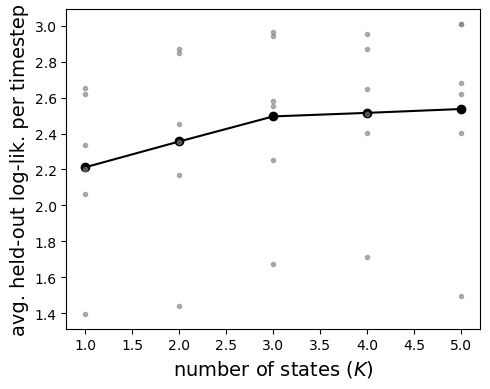

In [14]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(all_K, avg_lls, '-ko')
for K, fold_lls in zip(all_K, per_fold_lls):
    ax.plot(K * np.ones(len(fold_lls)), fold_lls, '.', color='gray', alpha=0.6)
ax.set_xlabel('number of states ($K$)', fontsize=fontsize)
ax.set_ylabel('avg. held-out log-lik. per timestep', fontsize=fontsize)
plt.tight_layout()

### Choosing $K$ with a significance test, not just the raw peak

We deliberately swept a narrow range, $K=1,\ldots,5$: performance climbs sharply then visibly flattens out
around $K=3$. But notice the raw numbers keep drifting up slightly all the way to $K=5$ &mdash; taking the
naive argmax over this range would give $K=5$, not the "obviously" flat $K=3$. Let's make the plateau
argument rigorous instead of eyeballing it: for each successive pair $(K, K{+}1)$, run a **paired** t-test
on the per-fold held-out log-likelihoods, and stop increasing $K$ the first time the next increase is no
longer significant. Paired, because the same six chunks are reused as test folds at every $K$ &mdash; some
chunks are just intrinsically harder to predict than others regardless of $K$, and pairing removes that
fold-to-fold difficulty as a nuisance variable rather than letting it inflate the variance of the
comparison.

In [15]:
from scipy import stats

per_fold_arrs = [np.array(f) for f in per_fold_lls]

print(f"{'K -> K+1':<10}{'mean diff':>12}{'two-sided p':>14}")
K_stop = None
for K in all_K[:-1]:
    diffs = per_fold_arrs[K] - per_fold_arrs[K - 1]   # all_K is 1-indexed; per_fold_arrs[K-1] is K, per_fold_arrs[K] is K+1
    t, p = stats.ttest_rel(per_fold_arrs[K], per_fold_arrs[K - 1])
    flag = "*" if p < 0.05 else ""
    print(f"{K} -> {K+1:<6}{diffs.mean():>12.4f}{p:>14.4f}  {flag}")
    if p >= 0.05 and K_stop is None:
        K_stop = K

best_K = K_stop
print(f"\nfirst non-significant increase is at K={K_stop} -> K={K_stop+1}, so we'll use best_K = {best_K}")

K -> K+1     mean diff   two-sided p
1 -> 2           0.1436        0.0038  *
2 -> 3           0.1397        0.0050  *
3 -> 4           0.0197        0.5863  
4 -> 5           0.0216        0.7169  

first non-significant increase is at K=3 -> K=4, so we'll use best_K = 3


**A cross-check.** A more standard alternative from the cross-validation literature is the
**one-standard-error rule** (Hastie, Tibshirani & Friedman, *Elements of Statistical Learning*): instead of
chaining pairwise tests, take the single best $K$, compute its standard error across folds, and pick the
*simplest* $K$ whose mean held-out likelihood is within one SE of the best.

In [16]:
se_at_best = per_fold_arrs[int(np.argmax(avg_lls))].std(ddof=1) / np.sqrt(len(data_chunks))
threshold = max(avg_lls) - se_at_best
K_1se = next(K for K, avg in zip(all_K, avg_lls) if avg >= threshold)

print(f"raw argmax over K=1..5: {all_K[int(np.argmax(avg_lls))]}")
print(f"SE at that K: {se_at_best:.4f}")
print(f"1-SE rule selects K = {K_1se}")

raw argmax over K=1..5: 5
SE at that K: 0.2291
1-SE rule selects K = 2


Here the two procedures actually disagree a little: the 1-SE rule lands on $K=2$, one step earlier
than the paired-test stopping rule's $K=3$. That's because the standard error at the best $K$ (driven
largely by that one consistently-hard-to-predict chunk) is wide enough that even $K=2$ is statistically
indistinguishable from the peak. This disagreement is itself informative &mdash; it tells us the choice
between $K=2$ and $K=3$ isn't crisply resolved by this data, unlike the clear, repeated improvement from
$K=1$ to $K=2$-or-$K=3$. We'll go with the paired-test result, $K=3$, since it's a more targeted comparison
(adjacent $K$'s, not "how close to the single best"), but a reasonable analyst running a different standard
procedure could defensibly land one step earlier.

**Is any of this fully valid?** Only as a diagnostic, not as a formal guarantee, and it's worth being upfront
about why:

1. **Multiple comparisons, uncorrected.** We ran 4 tests here without correcting for that; at a nominal
   $\alpha=0.05$ you'd expect a false positive every so often by chance alone, even if nothing were really
   changing.
2. **"Not significant" isn't "no difference."** With only 6 folds, a paired t-test has limited power &mdash;
   a real but modest improvement can easily fail to clear $p<0.05$. Stopping on a non-significant result
   conflates "we can't detect an effect" with "there is no effect."
3. **The folds aren't fully exchangeable.** One chunk is consistently harder to predict than the rest, at
   every $K$ (likely the stretch of recording with the most nonstationary dynamics). Pairing handles that
   for the *comparison*, but it's a reminder that "6 i.i.d. folds" is an approximation to a single
   nonstationary recording, not a literal sample of i.i.d. draws.
4. **We only looked as far as $K=5$.** Stopping the plateau argument at $K=5$ says nothing about whether a
   larger $K$ might do meaningfully better &mdash; that's exactly what Exercise 5 below asks you to check.

## Part 3: From AR-HMM to recurrent AR-HMM

So far the discrete states switch according to a plain Markov chain &mdash; transition probabilities don't
know where they are in state space. That's exactly the limitation that motivated **rSLDS** in lecture: we
added *recurrence*, letting the continuous state feed back into the discrete transition probabilities:

$$
p(z_t = k \mid z_{t-1}, x_{t-1}, u_t) \propto \exp\big(R_k^\top x_{t-1} + W_k^\top u_t + r_k\big)
$$

Here there's no separate continuous latent state to feed back &mdash; the AR-HMM's own (PCA-projected)
observations play that role directly. `ssm` builds both pieces from the same `M` (input dimension) and
`inputs` argument, so passing `inputs` to `.fit()` automatically feeds the intruder events into **both**
the transition probabilities above **and** the input-driven observation model from Part 2:

$$
x_t \mid z_t = k,\ u_t \ \sim\ N\big(A_k x_{t-1} + B_k u_t + b_k,\ Q_k\big)
$$

To isolate the effect of recurrence on its own, we'll fit two models at the same $K$, both with
input-driven observations, differing only in whether the transitions are recurrent.

In [17]:
# Standard transitions, input-driven observations
arhmm_std = ssm.HMM(best_K, D, M=n_inputs, observations="autoregressive", transitions="standard")
arhmm_std.fit(neural_pca, inputs=inputs, method="em", num_iters=500, verbose=0)
zhat_std = arhmm_std.most_likely_states(neural_pca, input=inputs)

# Recurrent transitions, input-driven observations
rarhmm = ssm.HMM(best_K, D, M=n_inputs, observations="autoregressive", transitions="recurrent_only")
lps_r = rarhmm.fit(neural_pca, inputs=inputs, method="em", num_iters=500, verbose=2)
zhat_r = rarhmm.most_likely_states(neural_pca, input=inputs)

  0%|          | 0/500 [00:00<?, ?it/s]

Before interpreting `rarhmm`'s results, let's sanity-check the fit itself. EM is only guaranteed to *monotonically increase* the training log-probability at every iteration when the E-step and M-step are both exact (see the math lecture note). Our E-step is exact (forward-backward), but the recurrent-transitions M-step has no closed form &mdash; `ssm` solves it with an iterative numerical optimizer, which can leave it just shy of its true optimum at any given EM iteration. So don't be surprised if the trace below has occasional, tiny decreases; what would actually indicate a bug is a *large* decrease, or a trace that doesn't clearly trend upward overall.

0 / 500 iterations decreased slightly (largest: 0.0000, out of a total increase of 682.0)


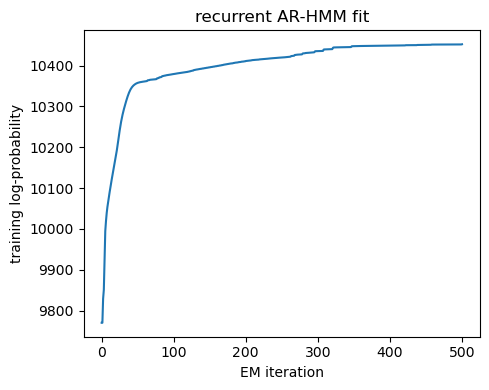

In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(lps_r, '-', ms=3)
ax.set_xlabel('EM iteration')
ax.set_ylabel('training log-probability')
ax.set_title('recurrent AR-HMM fit')
plt.tight_layout()

diffs = np.diff(lps_r)
print(f"{np.sum(diffs < 0)} / {len(diffs)} iterations decreased slightly "
      f"(largest: {diffs.min():.4f}, out of a total increase of {lps_r[-1] - lps_r[0]:.1f})")

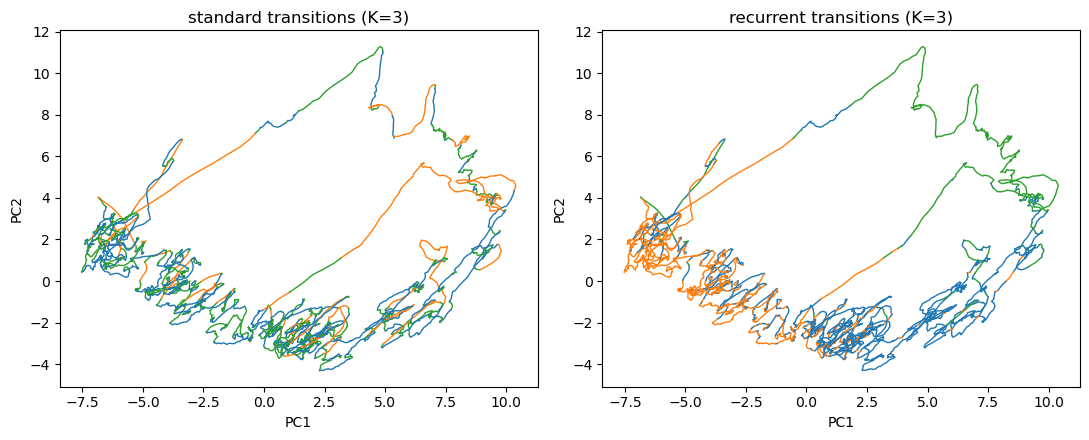

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))
plot_trajectory(zhat_std, neural_pca, ax=axs[0])
axs[0].set_title(f'standard transitions (K={best_K})')
axs[0].set_xlabel('PC1'); axs[0].set_ylabel('PC2')

plot_trajectory(zhat_r, neural_pca, ax=axs[1])
axs[1].set_title(f'recurrent transitions (K={best_K})')
axs[1].set_xlabel('PC1'); axs[1].set_ylabel('PC2')
plt.tight_layout()

Compare the two panels: with recurrent transitions, each color tends to occupy a contiguous region
of state space, rather than switching back and forth based on time alone. That's the same qualitative
change we saw going from SLDS to rSLDS in lecture &mdash; and since both models here have matched $K$ and
both use input-driven observations, this comparison isolates the effect of recurrence specifically.

## Part 4: Visualizing the inferred flow field

This is the same style of plot we used for rSLDS in lecture: at each point in state space, find the most
likely discrete state (from the recurrent transition weights), then draw that state's linear dynamics as
an arrow. This flow field is the *autonomous* dynamics, i.e. with $u_t = 0$; we'll also overlay the
input-driven shift $B_k u_t$ at the two intruder events, the same way the gpSLDS demo in lecture visualized
the learned input effect.

In [20]:
def plot_most_likely_dynamics_arhmm(model, xlim, ylim, nxpts=20, nypts=20,
                                     alpha=0.8, ax=None, figsize=(5, 5)):
    K = model.K
    x = np.linspace(*xlim, nxpts)
    y = np.linspace(*ylim, nypts)
    X, Y = np.meshgrid(x, y)
    xy = np.column_stack((X.ravel(), Y.ravel()))

    # Most likely state at each location, from the recurrent-only transition weights
    # (ignoring exogenous inputs, i.e. evaluating the "baseline" flow field)
    logits = xy.dot(model.transitions.Rs.T) + model.transitions.r
    z = np.argmax(logits, axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    As, bs = model.observations.As, model.observations.bs
    for k in range(K):
        A, b = As[k], bs[k]
        dxydt = xy.dot(A.T) + b - xy
        zk = z == k
        if np.any(zk):
            ax.quiver(xy[zk, 0], xy[zk, 1], dxydt[zk, 0], dxydt[zk, 1],
                      color=colors[k % len(colors)], alpha=alpha)

    ax.set_xlabel('PC1', fontsize=fontsize)
    ax.set_ylabel('PC2', fontsize=fontsize)
    return ax

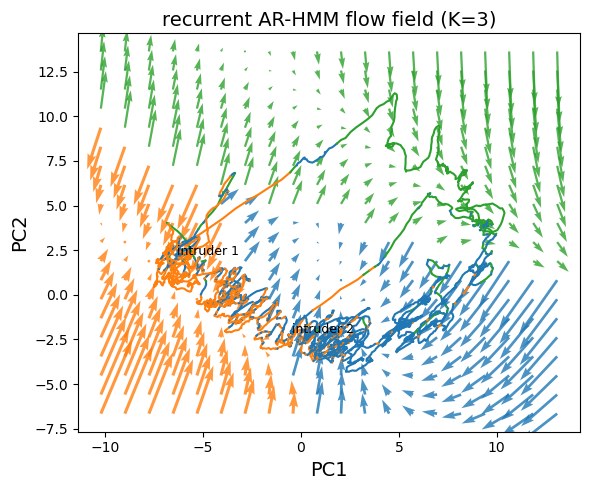

In [21]:
pad = 0.15 * (neural_pca.max(0) - neural_pca.min(0))
xlim = (neural_pca[:, 0].min() - pad[0], neural_pca[:, 0].max() + pad[0])
ylim = (neural_pca[:, 1].min() - pad[1], neural_pca[:, 1].max() + pad[1])

fig, ax = plt.subplots(figsize=(6, 5))
plot_most_likely_dynamics_arhmm(rarhmm, xlim=xlim, ylim=ylim, ax=ax)
plot_trajectory(zhat_r, neural_pca, ax=ax, lw=1.5)

# Overlay the input-driven shift B_k u_t at each intruder event, evaluated at the
# state that's active (and the location visited) when that intruder appears.
Vs = rarhmm.observations.Vs  # shape (K, D, M): B_k for each state k
for name, idx, u in [('intruder 1', input1_inds[0], np.array([1., 0.])),
                      ('intruder 2', input2_inds[0], np.array([0., 1.]))]:
    k = zhat_r[idx]
    loc = neural_pca[idx]
    effect = Vs[k].dot(u)
    ax.quiver(loc[0], loc[1], effect[0], effect[1],
              angles='xy', scale_units='xy', scale=1, color='black', width=0.008)
    ax.annotate(name, loc, fontsize=labelsize - 2)

ax.set_title(f'recurrent AR-HMM flow field (K={best_K})', fontsize=fontsize)
plt.tight_layout()

## Discussion

The flow field above is piecewise-linear, with hard boundaries between regimes and no notion of
uncertainty &mdash; exactly the two limitations of rSLDS that motivated **gpSLDS** in lecture. gpSLDS puts
a Gaussian process prior over the same kind of flow field, giving smooth transitions between regimes and a
calibrated posterior over the dynamics; **SING** is what made fitting that GP posterior fast. Same real
dataset, same qualitative story (a slow direction of integration), but a more expressive and better-
calibrated model.

**A note on the inputs.** We chose to always use input-driven observations above rather than treat it as
an open question, since it's the more general model and worth having by default for other projects during
the course. Whether it earns its keep on *this* dataset is a fair question &mdash; held-out likelihood over
$K=1,\ldots,5$ doesn't show a large or consistent gap between the input-driven and input-free versions here,
so don't take our use of it above as evidence that it obviously helps. Exercise 2 below asks you to check
this yourself.

### Exercises
1. Try `n_chunks` other than 6, or a wider/narrower range of `all_K` &mdash; how sensitive is the chosen
   $K$ to these choices?
2. Compare `cross_validate_arhmm(K, data_chunks)` (no inputs) against the input-driven sweep above, at the
   same $K$ values &mdash; does the input term earn back the extra parameters in held-out likelihood, or not
   really?
3. Refit on the full 56-neuron recording instead of the 2D PCA projection (you'll need to drop the flow-
   field plot, or reduce back to 2D just for visualization) &mdash; does held-out likelihood prefer more or
   fewer states than the 2D version?
4. *(Stretch)* Dynamax doesn't yet have a recurrent transition class. Sketch what one would need: a
   subclass of `dynamax`'s `HMMTransitions` whose transition logits are a function of the previous
   emission, mirroring `ssm.transitions.RecurrentOnlyTransitions` above.
5. Extend `all_K` to include $K=6$ (or further) and rerun the sweep and significance test from Part 2.
   You'll likely find $K=6$ scores a bit higher than $K=3$ on held-out likelihood, similar to what we saw
   before narrowing the range. Before concluding "$K=6$ is the better model," check the state occupancy of
   the $K=6$ fit from Part 3 (`np.bincount(zhat_r, minlength=6) / len(zhat_r)`) &mdash; in our run, the two
   least-used of the six states accounted for under 2% of all timesteps combined, i.e. the fit mostly acts
   like a 3-4 state model anyway. Two explanations are worth investigating, and they're not mutually
   exclusive: (a) there's some real, rare structure (perhaps around the intruder transients) that only shows
   up when the model has a spare state to give it; (b) **HMM fitting via EM is a non-convex optimization
   problem**, and `ssm`'s default initialization has a random component, so it can get stuck in different
   local optima on different runs. Giving EM more discrete states to allocate doesn't just add representational
   capacity &mdash; it changes the initialization and optimization landscape, which can help it escape a poor
   local optimum that a $K=3$ fit happens to land in. To test (b) directly, refit $K=3$ several times with
   different seeds (`cross_validate_arhmm(3, data_chunks, input_chunks=input_chunks, M=n_inputs, seed=...)`)
   and look at how much the result varies across restarts &mdash; in our run it ranged over roughly 0.16
   nats/timestep, comparable to the entire gap between $K=3$ and $K=6$, and the best $K=3$ restart we found
   actually beat most of our $K=6$ restarts. That doesn't prove $K=6$ has no real advantage, but it's a sign
   that at least part of the apparent gap is optimization noise, not a robust structural improvement.
6. In lecture, the VMHvl line attractor was identified by inspecting the eigenvalues of the fitted dynamics
   matrix: a line attractor shows one eigenvalue very close to 1 (a slow, weakly-decaying integration
   direction) alongside a much smaller eigenvalue (a fast direction that collapses trajectories onto the
   slow one). Pick out whichever state looks most "attractor-like" in your K=3 flow field &mdash; in our run
   that's the orange state, state index 1 &mdash; and extract its dynamics matrix, `A = rarhmm.observations.As[1]`.
   Compute its eigenvalues (`np.linalg.eigvals(A)`) and convert each to a time constant in seconds via
   $\tau = -dt / \ln|\lambda|$ (here $dt = 1/10$ s), the time for a perturbation along that eigendirection to
   decay to $1/e$ of its initial size. Heads up: when we did this, all three K=3 states turned out to have a
   slow mode with $|\lambda| > 0.97$ (time constants of several seconds to over a minute) &mdash; not just the
   state that looked attractor-like, and one state's slow eigenvalue was actually slightly *above* 1 (locally
   unstable, which is fine as a local approximation since recurrent transitions kick the system into another
   state before it could diverge). Compute eigenvalues for all three states and compare them. Is the
   "attractor" state's slow mode meaningfully different from the others, or might a near-unity eigenvalue
   just be a generic feature of fitting *any* locally-linear model to a slowly-varying signal sampled at 10 Hz
   (i.e. a mundane consequence of strong autocorrelation between consecutive 100&nbsp;ms samples, present
   whether or not there's real attractor structure)? How might you distinguish genuine line-attractor
   structure from that generic slow-sampling effect &mdash; e.g. is the slow eigenvector's direction stable
   across independent refits with different seeds, or does it align with a specific behavioral variable, the
   way Nair et al. (2023) tied it to aggression?
7. So far we've fit AR-HMMs directly to the 2D PCA projection, treating `neural_pca` as if it were noise-free
   ground truth. A full rSLDS instead treats the low-dimensional trajectory as a *latent* variable to be
   inferred jointly with the dynamics from noisy observations of all 56 neurons &mdash; this is what actually
   produced the line-attractor result in lecture. Before running anything: what differences would you expect
   between the 2D trajectory recovered by an rSLDS and the one you get from a plain PCA projection? Then fit
   one to check your prediction:
   ```python
   rslds = ssm.SLDS(n_neurons, K, D, transitions="recurrent_only", dynamics="diagonal_gaussian",
                     emissions="gaussian_orthog", single_subspace=True)
   rslds.initialize(norm_neural)
   q_elbos, q = rslds.fit(norm_neural, method="laplace_em", variational_posterior="structured_meanfield",
                           initialize=False, num_iters=50, alpha=0.0)
   xhat = q.mean_continuous_states[0]
   ```
   (fits in well under a minute on this dataset). Compare `xhat` to `neural_pca`: the overall trajectory
   shape should look similar (same slow structure), but is `xhat` smoother moment to moment? Try quantifying
   "roughness" as the mean squared step-to-step difference,
   `np.mean(np.sum(np.diff(x, axis=0)**2, axis=1))`, for each. In our run the rSLDS-inferred trajectory's
   roughness was about 45% of the raw PCA trajectory's &mdash; a substantial reduction, but far from all of
   it, consistent with your hunch. That's the signature of the dynamics prior acting like a Kalman smoother:
   it pulls the inferred trajectory toward what the fitted dynamics $A x_{t-1} + b$ predict and away from
   whatever is unpredictable moment-to-moment across 56 noisy channels, while any real, fast structure in the
   underlying dynamics (not just observation noise) should survive that smoothing. Do you see features of
   `neural_pca` that persist in `xhat`, and features that don't? (One wrinkle: `xhat`'s two dimensions won't
   be aligned to `neural_pca`'s PC1/PC2 &mdash; `gaussian_orthog` emissions are fit jointly with the dynamics
   to maximize likelihood, not fit to maximize variance the way PCA is, so expect a rotation/reflection, not
   an exact match. The roughness metric above is invariant to that.)

### References
- Linderman et al. (2017). Bayesian learning and inference in recurrent switching linear dynamical systems.
- Wiltschko et al. (2015). Mapping sub-second structure in mouse behavior. *Neuron*. (MoSeq)
- Nair, Vinograd et al. (2023). An approximate line attractor in the hypothalamus. *Cell*.
- Vinograd, Nair et al. (2024). Causal evidence for a line attractor in the hypothalamus. *Nature*.
- Hu et al. (2024). Modeling latent neural dynamics with gaussian process switching linear dynamical
  systems. *NeurIPS*.
- Hu, Smith & Linderman (2025). SING: natural gradient variational inference for non-conjugate SDEs.
  *NeurIPS*.
- `ssm`: github.com/lindermanlab/ssm
- `dynamax`: github.com/probml/dynamax
- `sing`: github.com/lindermanlab/sing